# Laboratorio 5 — Agentes en el Arcade Learning Environment (ALE): Space Invaders

**CC3092 — Deep Learning y Sistemas Inteligentes · Sección 20 · Javier Fong**

Fernando Andree Hernández Martínez — 23645

El objetivo del laboratorio es dejar funcionando la infraestructura que conecta un agente con un
entorno de Atari 2600 a través de Gymnasium y ALE: creación del entorno, política, loop de episodio
y grabación de video. No se entrena ningún agente; se usan un agente aleatorio (baseline) y un
agente de regla simple.

## 1. El Arcade Learning Environment (ALE)

### ¿Qué es ALE y qué problema resuelve?

El Arcade Learning Environment es una plataforma que expone cientos de juegos de Atari 2600 como
entornos de aprendizaje por refuerzo con una interfaz uniforme (`reset`, `step`, observación,
recompensa, fin de episodio). Fue presentado por Bellemare et al. (2013) para resolver un problema
metodológico del área: antes de ALE cada trabajo evaluaba sus algoritmos en entornos hechos a la
medida, lo que hacía imposible comparar resultados. ALE aporta un banco de pruebas grande, variado y
difícil, donde todos los juegos comparten el mismo espacio de entrada (la pantalla) y el mismo tipo
de control (el joystick), de modo que un mismo algoritmo puede evaluarse en decenas de tareas sin
cambiar nada del agente.

### Relación con Stella y con los juegos originales

ALE no reimplementa los juegos: es una capa construida sobre **Stella**, un emulador de código
abierto del Atari 2600. Stella ejecuta la ROM original del cartucho —el mismo binario que corría en
la consola de 1980— y ALE se acopla al emulador para leer el framebuffer (210x160 píxeles), leer los
128 bytes de RAM, inyectar las acciones del joystick y extraer del marcador la señal de recompensa.
Desde `ale-py` 0.10 las ROMs vienen empaquetadas con la librería, así que no hay que conseguirlas
aparte.

### Variantes de un mismo juego

Un mismo juego se expone con varias configuraciones:

- **Versión `-v5`** (`ALE/SpaceInvaders-v5`): es la recomendada porque sigue las buenas prácticas de
  Machado et al. (2018). Por defecto usa `frameskip=4`, `repeat_action_probability=0.25` y
  `full_action_space=False`. Las versiones anteriores (`-v0`, `-v4`) difieren en estos valores y en
  el manejo de vidas.
- **`obs_type`**: `rgb` (defecto, imagen 210x160x3), `grayscale` (210x160) y `ram` (vector de 128
  bytes). En la nomenclatura antigua estas variantes aparecían como sufijos en el id del entorno
  (`SpaceInvaders-ram-v4`); en la moderna se piden con `gym.make(..., obs_type="ram")`.
- **`frameskip`**: cuántos frames del emulador avanza cada `step`. Puede ser un entero (determinista)
  o una tupla `(min, max)` para muestrear el salto y añadir estocasticidad.
- **`repeat_action_probability`**: *sticky actions*. Con probabilidad 0.25 el emulador repite la
  acción anterior en lugar de la enviada. Evita que un agente resuelva el juego memorizando una
  secuencia fija de acciones, que era la forma degenerada de "ganar" en las versiones deterministas.
- **`full_action_space`**: si es `True` el espacio de acción es `Discrete(18)` (todas las
  combinaciones del joystick) para todos los juegos; si es `False`, solo las acciones con efecto en
  ese juego, que en Space Invaders son 6.

### Frame skipping

Con frame skipping el agente elige una acción cada *k* frames y esa acción se repite en los frames
intermedios; solo se le devuelve la observación del último (o el máximo píxel a píxel de los dos
últimos, para lidiar con el parpadeo de sprites del Atari). Importa por tres razones:

1. **Velocidad**: se emulan 60 frames por segundo de juego, pero la red solo hace una inferencia
   cada 4, de modo que el costo de cómputo del agente baja ~4x.
2. **Horizonte efectivo**: un episodio deja de medir decenas de miles de pasos para medir unos
   pocos miles, lo que acorta las cadenas de crédito temporal que el algoritmo debe propagar.
3. **Control**: a 60 Hz dos frames consecutivos son casi idénticos y una sola acción casi no cambia
   nada; agrupando 4 frames cada decisión tiene un efecto observable.

El costo es la pérdida de reactividad: con un salto muy grande el agente no alcanza a reaccionar a
eventos rápidos. El valor estándar en la literatura es 4 (en Space Invaders algunos trabajos usan 3
para no perder el parpadeo de los láseres).

### Space Invaders: mecánica y recompensa

El jugador controla un cañón que se mueve horizontalmente en la parte baja de la pantalla y dispara
hacia arriba, contra una formación de 6x6 invasores que desciende y se desplaza de lado a lado
acelerando conforme quedan menos. Tres búnkeres destructibles protegen al jugador, que tiene tres
vidas y las pierde al ser alcanzado por los disparos enemigos; el juego también termina si los
invasores llegan hasta abajo. Cada cierto tiempo cruza una nave nodriza que vale puntos extra.

La recompensa del entorno es exactamente el **incremento del marcador original** en el intervalo que
cubre cada `step`: entre 5 y 30 puntos por invasor según la fila y entre 50 y 200 por la nave
nodriza. No hay recompensas negativas por perder vidas, así que la señal es no negativa y dispersa,
y el *return* sin descuento de un episodio coincide con el puntaje final de la partida.

## 2. Espacios de observación y acción

### Observación por defecto vs. CartPole

`ALE/SpaceInvaders-v5` entrega `Box(0, 255, (210, 160, 3), uint8)`: el frame RGB completo del
emulador, 100 800 valores por observación. `CartPole-v1` entrega `Box(4,)` en `float32` con
posición, velocidad, ángulo y velocidad angular del sistema.

Las implicaciones de trabajar con imágenes son:

- **Dimensionalidad y arquitectura**: un MLP sobre 100 800 entradas es inviable, por lo que se usan
  redes convolucionales, que además aportan invarianza traslacional (un invasor se ve igual en
  cualquier columna).
- **Estado latente**: el vector de CartPole *es* el estado; la imagen no. La posición se ve, pero la
  velocidad y la dirección de los proyectiles no se pueden inferir de un solo frame, por lo que el
  problema es parcialmente observable y se resuelve apilando frames.
- **Preprocesamiento obligatorio**: hay que reducir a escala de grises, recortar el marcador,
  redimensionar y normalizar para que el entrenamiento sea manejable en memoria y tiempo.
- **Muestras necesarias**: aprender de píxeles requiere órdenes de magnitud más interacciones
  (millones de pasos) que aprender de un vector de cuatro números (decenas de miles).

### Observación en RAM

Con `obs_type="ram"` la observación son los 128 bytes de memoria de la consola, donde están
codificadas directamente variables del juego (posición del cañón, estado de la formación, vidas,
puntaje). Conviene cuando: se quiere entrenar rápido y barato sin una CNN, se necesita un baseline
compacto para probar el algoritmo, se quiere estudiar el problema de control separado del de visión,
o se quiere inspeccionar/derivar variables del juego para diseñar heurísticas y recompensas
auxiliares. Sus desventajas son que la representación es opaca (los bytes no tienen semántica
declarada y cambian de juego a juego), no es transferible entre juegos y no es comparable con los
resultados estándar de la literatura, que se reportan sobre píxeles.

### Acciones de Space Invaders

Con `full_action_space=False` el espacio es `Discrete(6)`:

| Índice | Acción | Efecto |
| --- | --- | --- |
| 0 | `NOOP` | No hacer nada; el cañón mantiene su posición y no dispara. |
| 1 | `FIRE` | Disparar sin moverse. |
| 2 | `RIGHT` | Mover el cañón a la derecha. |
| 3 | `LEFT` | Mover el cañón a la izquierda. |
| 4 | `RIGHTFIRE` | Mover a la derecha disparando en el mismo paso. |
| 5 | `LEFTFIRE` | Mover a la izquierda disparando en el mismo paso. |

Las acciones compuestas importan: solo hay un láser propio en pantalla a la vez, así que la política
eficiente consiste en reposicionarse mientras se dispara en lugar de alternar entre moverse y
disparar.

### `AtariPreprocessing` y `FrameStackObservation`

`gymnasium.wrappers.AtariPreprocessing` empaqueta el preprocesamiento estándar del paper de DQN:

- `noop_max=30`: de 0 a 30 acciones `NOOP` aleatorias al inicio, para diversificar los estados
  iniciales de un emulador determinista.
- `frame_skip=4` con *max-pooling* de los dos últimos frames, que elimina el parpadeo de sprites.
- `grayscale_obs=True`: de 3 canales a 1 (el color no aporta información de control).
- `screen_size=84`: redimensiona a 84x84, reduciendo la observación de 100 800 a 7 056 valores.
- `terminal_on_life_loss`: opcionalmente marca fin de episodio al perder una vida, lo que densifica
  la señal de fracaso.
- `scale_obs` / `clip_reward`: normaliza los píxeles a [0,1] y recorta la recompensa a su signo para
  que la escala de puntajes sea comparable entre juegos.

`FrameStackObservation(env, stack_size=4)` (antes `FrameStack`) apila las últimas 4 observaciones en
un tensor `(4, 84, 84)`. Se usa junto con el anterior porque un frame estático no contiene
velocidad ni dirección: con cuatro frames la red puede inferir hacia dónde se mueve la formación y
qué proyectiles están cayendo, recuperando aproximadamente la propiedad de Markov que el algoritmo
asume.

**Nota sobre el laboratorio:** los agentes de este trabajo (aleatorio y de regla simple) no
aprenden, por lo que los videos se graban sobre el entorno sin preprocesar, que conserva el color,
la resolución original y la recompensa sin recortar.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# El módulo del laboratorio vive en src/.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import ale_py
import gymnasium as gym

from ale_utils import (
    agente_aleatorio,
    agente_regla_simple,
    crear_entorno,
    ejecutar_episodio,
    fijar_semillas,
    generar_video_agente,
)
from config import DIR_VIDEOS, ENTORNO_CARTPOLE, ENTORNO_SPACE_INVADERS, MAX_STEPS, SEMILLA

fijar_semillas(SEMILLA)

print("gymnasium", gym.__version__)
print("ale-py", ale_py.__version__)
print("semilla", SEMILLA)

gymnasium 1.3.0
ale-py 0.12.1
semilla 42


### 2.1 Inspección de los espacios

In [2]:
env = crear_entorno(ENTORNO_SPACE_INVADERS)
observation, info = env.reset(seed=SEMILLA)

print("Space Invaders")
print("  observación:", env.observation_space)
print("  acción:     ", env.action_space)
print("  acciones:   ", env.unwrapped.get_action_meanings())
print("  info reset: ", info)
print("  kwargs:     ", env.spec.kwargs)

cartpole = crear_entorno(ENTORNO_CARTPOLE)
print("\nCartPole")
print("  observación:", cartpole.observation_space)
print("  acción:     ", cartpole.action_space)
print("  valores por observación:", np.prod(cartpole.observation_space.shape),
      "vs", np.prod(env.observation_space.shape), "en Space Invaders")
cartpole.close()

Space Invaders
  observación: Box(0, 255, (210, 160, 3), uint8)
  acción:      Discrete(6)
  acciones:    ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']
  info reset:  {'lives': 3, 'episode_frame_number': 0, 'frame_number': 0, 'seeds': (np.uint32(3444837047), np.uint32(2669555309))}
  kwargs:      {'game': 'space_invaders', 'repeat_action_probability': 0.25, 'full_action_space': False, 'frameskip': 4, 'max_num_frames_per_episode': 108000, 'render_mode': None}

CartPole
  observación: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  acción:      Discrete(2)
  valores por observación: 4 vs 100800 en Space Invaders


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


### 2.2 Variantes de observación y wrappers

In [3]:
# Observación en RAM: los 128 bytes de la consola en lugar de la pantalla.
env_ram = crear_entorno(ENTORNO_SPACE_INVADERS, obs_type="ram")
obs_ram, _ = env_ram.reset(seed=SEMILLA)
print("RAM:", env_ram.observation_space, "->", obs_ram[:16], "...")
env_ram.close()

# Pipeline estándar de Atari: preprocesamiento + apilado de frames.
# frameskip=1 en el entorno base porque AtariPreprocessing aplica el suyo.
env_prep = gym.make(ENTORNO_SPACE_INVADERS, frameskip=1)
env_prep = gym.wrappers.AtariPreprocessing(env_prep, grayscale_obs=True, screen_size=84)
env_prep = gym.wrappers.FrameStackObservation(env_prep, stack_size=4)
obs_prep, _ = env_prep.reset(seed=SEMILLA)
print("Preprocesado + apilado:", env_prep.observation_space, "->", obs_prep.shape)
env_prep.close()

RAM: Box(0, 255, (128,), uint8) -> [  0   7   0  68 241 162  34 183  68  13 124 255 255  50 255 255] ...


Preprocesado + apilado: Box(0, 255, (4, 84, 84), uint8) -> (4, 84, 84)


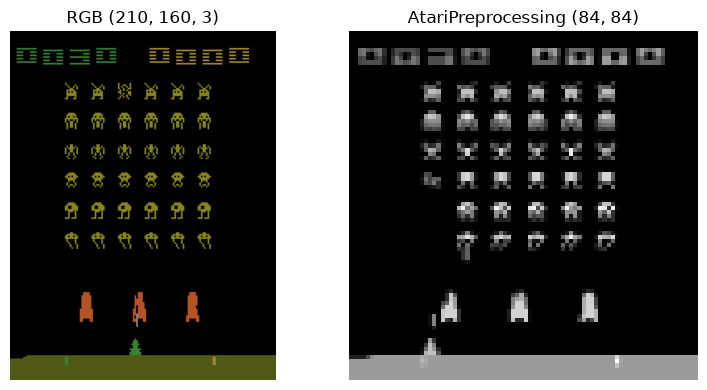

In [4]:
# Comparación visual: frame RGB original vs. observación preprocesada a 84x84.
env_vis = gym.make(ENTORNO_SPACE_INVADERS)
obs_rgb, _ = env_vis.reset(seed=SEMILLA)
for _ in range(120):
    obs_rgb, *_ = env_vis.step(agente_regla_simple(obs_rgb, env_vis))
env_vis.close()

env_vis = gym.make(ENTORNO_SPACE_INVADERS, frameskip=1)
env_vis = gym.wrappers.AtariPreprocessing(env_vis, grayscale_obs=True, screen_size=84)
obs_g, _ = env_vis.reset(seed=SEMILLA)
for _ in range(120):
    obs_g, *_ = env_vis.step(1)
env_vis.close()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(obs_rgb)
axes[0].set_title(f"RGB {obs_rgb.shape}")
axes[1].imshow(obs_g, cmap="gray")
axes[1].set_title(f"AtariPreprocessing {obs_g.shape}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Módulo de funciones (`src/ale_utils.py`)

| Función | Qué hace |
| --- | --- |
| `crear_entorno(nombre_entorno, video_folder, name_prefix, episode_trigger, render_mode, **kwargs)` | Crea cualquier entorno de Gymnasium por su id. Si recibe `video_folder`, fuerza `render_mode="rgb_array"` y lo envuelve en `RecordVideo` con el `episode_trigger` indicado (por defecto graba todos los episodios). |
| `agente_aleatorio(observation, env)` | Baseline sin entrenamiento: retorna `env.action_space.sample()`. |
| `agente_regla_simple(observation, env)` | Heurística sobre píxeles: localiza el cañón por su color verde en las filas inferiores y el centroide de los invasores en la banda central, y retorna `RIGHTFIRE`/`LEFTFIRE` para alinearse o `FIRE` si ya está alineado. |
| `ejecutar_episodio(env, funcion_agente, max_steps, seed)` | Corre un episodio completo hasta `terminated` o `truncated` (o `max_steps`) y retorna pasos, recompensa total, `terminated` y `truncated`. |
| `generar_video_agente(nombre_entorno, funcion_agente, video_folder, name_prefix, n_episodios, ...)` | Función de alto nivel: crea el entorno con grabación, corre los episodios, hace `env.close()` (indispensable para que el `.mp4` se escriba) y retorna las rutas de los videos junto con las métricas de cada episodio. |

Nota de reproducibilidad: `env.reset(seed=...)` siembra el generador del entorno pero **no** el del
espacio de acción, del que muestrea el agente aleatorio, así que `ejecutar_episodio` también llama a
`env.action_space.seed(seed)`.

In [5]:
# Un episodio de cada agente, sin grabar, para verificar el loop.
for nombre, funcion in [("aleatorio", agente_aleatorio), ("regla simple", agente_regla_simple)]:
    metricas = ejecutar_episodio(env, funcion, max_steps=MAX_STEPS, seed=SEMILLA)
    print(f"{nombre:>13}: {metricas['pasos']:>5} pasos, "
          f"recompensa {metricas['recompensa_total']:>6.0f}, "
          f"terminated={metricas['terminated']}")
env.close()

    aleatorio:   325 pasos, recompensa     65, terminated=True


 regla simple:  1121 pasos, recompensa    380, terminated=True


## 4. Generación de los videos entregables

Se graban tres episodios completos del agente aleatorio (el entregable obligatorio) y uno del agente
de regla simple, en `entregables/videos/`.

In [6]:
fijar_semillas(SEMILLA)

resultado_aleatorio = generar_video_agente(
    ENTORNO_SPACE_INVADERS,
    agente_aleatorio,
    video_folder=str(DIR_VIDEOS),
    name_prefix="aleatorio-space-invaders",
    n_episodios=3,
    max_steps=MAX_STEPS,
    seed=SEMILLA,
)

resultado_regla = generar_video_agente(
    ENTORNO_SPACE_INVADERS,
    agente_regla_simple,
    video_folder=str(DIR_VIDEOS),
    name_prefix="regla-simple-space-invaders",
    n_episodios=1,
    max_steps=MAX_STEPS,
    seed=SEMILLA,
)

for nombre, resultado in [("aleatorio", resultado_aleatorio), ("regla simple", resultado_regla)]:
    print(f"\nAgente {nombre}")
    for episodio, video in zip(resultado["episodios"], resultado["videos"]):
        print(f"  episodio {episodio['episodio']}: {episodio['pasos']} pasos sobrevividos, "
              f"recompensa total {episodio['recompensa_total']:.0f}")
        print(f"    video: {Path(video).name}")

/Users/ferahmz/Documents/uvg/octavo/Deep Learning/space-invaders-dpl/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/ferahmz/Documents/uvg/octavo/Deep Learning/space-invaders-dpl/entregables/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


/Users/ferahmz/Documents/uvg/octavo/Deep Learning/space-invaders-dpl/.venv/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/ferahmz/Documents/uvg/octavo/Deep Learning/space-invaders-dpl/entregables/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(



Agente aleatorio
  episodio 0: 325 pasos sobrevividos, recompensa total 65
    video: aleatorio-space-invaders-episode-0.mp4
  episodio 1: 601 pasos sobrevividos, recompensa total 215
    video: aleatorio-space-invaders-episode-1.mp4
  episodio 2: 434 pasos sobrevividos, recompensa total 50
    video: aleatorio-space-invaders-episode-2.mp4

Agente regla simple
  episodio 0: 1121 pasos sobrevividos, recompensa total 380
    video: regla-simple-space-invaders-episode-0.mp4


In [7]:
from IPython.display import Video

Video(resultado_aleatorio["videos"][0], embed=True, width=320)

## 5. Comparación entre agentes

Cinco episodios por agente con semillas distintas, para contrastar el baseline aleatorio con la
heurística.

In [8]:
N_EPISODIOS = 5
resultados = {}

for nombre, funcion in [("aleatorio", agente_aleatorio), ("regla simple", agente_regla_simple)]:
    env_eval = crear_entorno(ENTORNO_SPACE_INVADERS)
    corridas = [
        ejecutar_episodio(env_eval, funcion, max_steps=MAX_STEPS, seed=SEMILLA + i)
        for i in range(N_EPISODIOS)
    ]
    env_eval.close()
    resultados[nombre] = corridas

    recompensas = [r["recompensa_total"] for r in corridas]
    pasos = [r["pasos"] for r in corridas]
    print(f"{nombre:>13}: recompensa media {np.mean(recompensas):6.1f} "
          f"(min {min(recompensas):.0f}, max {max(recompensas):.0f}) | "
          f"pasos medios {np.mean(pasos):6.1f}")

    aleatorio: recompensa media  109.0 (min 50, max 215) | pasos medios  477.8


 regla simple: recompensa media  391.0 (min 195, max 590) | pasos medios 1121.0


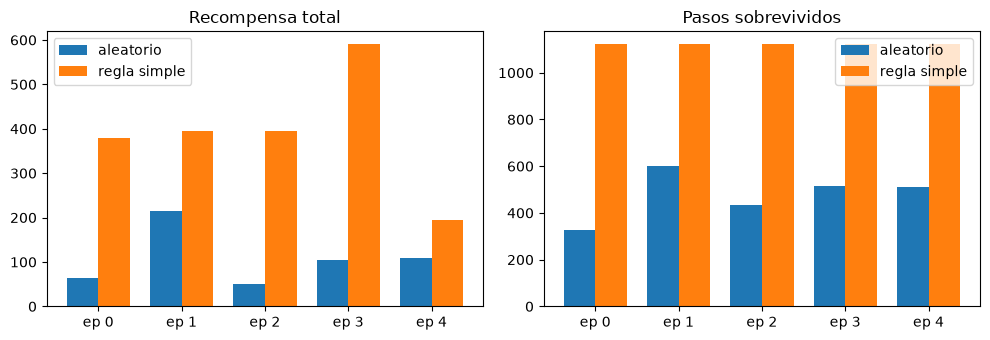

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
etiquetas = list(resultados)
x = np.arange(N_EPISODIOS)

for i, clave in enumerate(["recompensa_total", "pasos"]):
    for j, nombre in enumerate(etiquetas):
        valores = [r[clave] for r in resultados[nombre]]
        axes[i].bar(x + j * 0.38, valores, width=0.38, label=nombre)
    axes[i].set_xticks(x + 0.19)
    axes[i].set_xticklabels([f"ep {k}" for k in range(N_EPISODIOS)])
    axes[i].set_title("Recompensa total" if i == 0 else "Pasos sobrevividos")
    axes[i].legend()

plt.tight_layout()
plt.show()

## 6. Discusión

- **La infraestructura queda validada de punta a punta.** `crear_entorno` funciona igual con
  `ALE/SpaceInvaders-v5` y con `CartPole-v1`, `ejecutar_episodio` corre episodios completos hasta
  `terminated` y `generar_video_agente` deja los `.mp4` en disco; el `env.close()` dentro de un
  `finally` es lo que garantiza que el último video se escriba aunque el loop falle.
- **El baseline aleatorio obtiene recompensa distinta de cero** porque dos de las seis acciones
  disparan y una fracción de esos disparos acierta por azar; sirve como piso contra el cual medir
  cualquier agente entrenado, no como política razonable.
- **Una heurística de pocas líneas ya supera claramente al azar** en recompensa y en supervivencia,
  simplemente por alinear el cañón con la formación y disparar mientras se mueve. Esto muestra que
  gran parte de la señal está en información espacial fácil de extraer del frame, y a la vez que la
  heurística topa techo rápido: no esquiva proyectiles, no aprovecha los búnkeres ni la nave nodriza,
  y ninguna de sus decisiones mejora con la experiencia.
- **El agente de regla simple sobrevive exactamente 1 121 pasos en las cinco semillas**, mientras su
  recompensa varía entre 195 y 590. Al quedarse siempre debajo de la formación y no esquivar nada,
  el momento en que pierde sus tres vidas queda fijado por el descenso de los invasores y no por
  decisiones propias; lo único que cambia entre corridas es cuántos aciertos logra en ese tiempo.
- **La varianza entre episodios es alta** (los `sticky actions` con probabilidad 0.25 y los `NOOP`
  iniciales aleatorios hacen que dos corridas con la misma política difieran mucho), por lo que
  comparar agentes con un solo episodio no es concluyente: el reporte estándar promedia decenas de
  episodios.
- **Lo que falta para entrenar** es enchufar `AtariPreprocessing` + `FrameStackObservation` a este
  mismo `crear_entorno` y sustituir la función de agente por una política aprendida; el resto del
  código —loop de episodio, métricas y grabación— se reutiliza sin cambios.